# On Monday's 24-order sample, do Retail-Plus baskets beat Retail-Core's, or is the lead the wobble chance makes?

**Week 1, Thursday. The TA-led practice lab, problem 3: 20 minutes, in pairs.** Five lettered choices
on Monday's take-home sample.

> **The client asks.** "Do Retail-Plus members really buy bigger baskets than Retail-Core, or is that
> just what we expect of a paid tier?" The head of Retail-Plus

**Who needs the answer.** The head of Retail-Plus, who watches whether members' fees cover what their
benefits cost and would put bigger baskets into that case. A lead that chance or a definition made
would carry the case on a difference that is not there.

**The questions on the way.**

1. Do Retail-Plus baskets lead on every booked order, and how often does chance make that lead?
2. Does the lead survive on the money Kalpa kept, and which share goes in the line?

The setup cell below loads Monday's take-home sample, 24 orders you have already counted once.
Retail-Plus and Retail-Core are Kalpa Retail's two consumer tiers, of which Retail-Plus is the paid
membership; the sample also holds Student orders and Business orders, Business being Kalpa's sales
to companies. A basket is one order's amount. Booked orders are every order placed, whatever
happened to it afterwards. Which orders count as the money Kalpa kept is Monday's definition, and
recalling it is marker 4's question, so it is not repeated here. Chapter 1 flipped each Retail-Plus
member's two quarters because the same members sat in both; the two tiers' baskets are different
customers' orders, with no pairs to flip, so the chance reference here is the label shuffle, as in
chapter 6: `shuffle_gaps` pools every basket and deals the baskets at random into two piles of the
tiers' sizes, 5,000 times, and the share, the p-value, is the fraction of deals that make a lead at
least as large as the real one; a lead that chance makes often is part of the usual wobble, the
movement chance alone makes between two groups. Chapter 3's rule of thumb is to distrust a
comparison with fewer than thirty customers behind it.

**This is the solution.** Every choice is filled with its key line, the notebook runs clean from a fresh
kernel, and the reason for each letter follows the cell that carries it.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random

ORDERS = kit.load_records("C2_W01_D04_monday_sample_STUDENT.py")


def mean(values):
    return sum(values) / len(values)


def shuffle_gaps(q1, q2, times, seed):
    """Two groups of different customers: deal every value to two piles at random, many times."""
    random.seed(seed)
    pool = q1 + q2
    gaps = []
    for _ in range(times):
        random.shuffle(pool)
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


print(len(ORDERS), "orders in Monday's sample")

24 orders in Monday's sample


## Step 1. Do Retail-Plus baskets lead on every booked order, and how often does chance make that lead?

Used at work whenever two customer groups are compared on a small file.

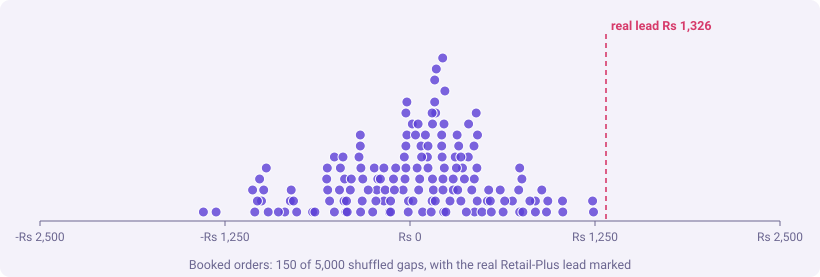

Retail-Plus 8 orders at Rs 3,420, Retail-Core 11 at Rs 2,093; lead Rs 1,326, share 0.002


In [2]:
# TODO 1. Which orders belong in a basket comparison between the two consumer tiers?
#   a) r["segment"] != "Student"
#   b) True
#   c) r["segment"] in ("Retail-Plus", "Retail-Core")
#   d) r["segment"] in ("Retail-Plus", "Retail-Core", "Business")
tiers = [r for r in ORDERS if r["segment"] in ("Retail-Plus", "Retail-Core")]
# TODO 2. How does each amount become a number the loop can average?
#   a) int(r["amount"])
#   b) r["amount"]
#   c) int(r["amount"]) if r["status"] == "delivered" else 0
#   d) len(str(r["amount"]))
plus = [int(r["amount"]) for r in tiers if r["segment"] == "Retail-Plus"]
core = [int(r["amount"]) for r in tiers if r["segment"] == "Retail-Core"]
real = mean(plus) - mean(core)
gaps = shuffle_gaps(plus, core, 5000, seed=2026)
# TODO 3. Which share is the p-value for a Retail-Plus lead at least as large?
#   a) sum(1 for g in gaps if g <= real) / len(gaps)
#   b) sum(1 for g in gaps if g >= real) / len(gaps)
#   c) real / max(gaps)
#   d) sum(1 for g in gaps if abs(g) >= abs(real) * 2) / len(gaps)
share_booked = sum(1 for g in gaps if g >= real) / len(gaps)
kit.strip(gaps[:150], markers=[("real lead", real, "bad")], lo=-2500, hi=2500,
          title="Booked orders: 150 of 5,000 shuffled gaps, with the real Retail-Plus lead marked")
print(f"Retail-Plus {len(plus)} orders at {kit.rupees(mean(plus))}, Retail-Core {len(core)} at {kit.rupees(mean(core))}; "
      f"lead {kit.rupees(real)}, share {share_booked:.3f}")

**TODO 1 is c.** The question is about the two consumer tiers. a keeps Business, whose lakh-rupee orders would swamp any basket comparison; b keeps everyone; d names Business outright.

**TODO 2 is a.** Every amount in this file converts cleanly with int(), including the one stored as text, which is Monday's lesson. b leaves text in the list, so the average stops with a TypeError; c zeroes every order that was not delivered, which answers step 2's question in step 1 and keeps the cancelled orders in the count at zero; d measures the length of the text.

**TODO 3 is b.** A Retail-Plus lead at least as large as the real one is a shuffled gap at or above it. a counts every shuffled gap at or below the real lead, which is nearly every deal; c is a ratio with no count of worlds; d asks for a gap twice as large.

In [3]:
kit.check("the comparison holds the 19 booked orders of the two tiers", len(tiers) == 19, f"{len(tiers)}")
kit.check("on booked orders Retail-Plus leads by Rs 1,326 an order", round(real) == 1326, kit.rupees(real))
kit.check("counting leads at least as large, the booked share is 0.002 with seed 2026", round(share_booked, 3) == 0.002,
          f"{share_booked:.3f}")

## Step 2. Does the lead survive on the money Kalpa kept, and which share goes in the line?

Used at work whenever a definition decides which orders count.

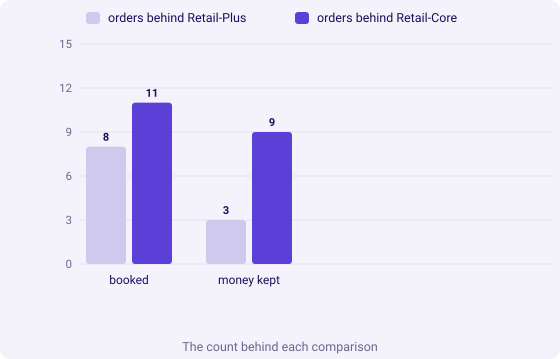

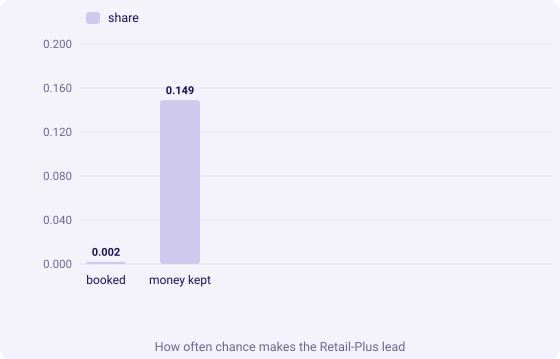

on the money kept, Retail-Plus has 3 orders and leads by Rs 671; the line reports a share of 0.149, about 15 times in 100


In [4]:
# TODO 4. Which filter keeps only the money kept?
#   a) r["status"] != "cancelled"
#   b) r["status"] == "returned" or r["status"] == "delivered"
#   c) r["amount"] != ""
#   d) r["status"] == "delivered"
kept = [r for r in tiers if r["status"] == "delivered"]
plus_k = [int(r["amount"]) for r in kept if r["segment"] == "Retail-Plus"]
core_k = [int(r["amount"]) for r in kept if r["segment"] == "Retail-Core"]
real_k = mean(plus_k) - mean(core_k)
gaps_k = shuffle_gaps(plus_k, core_k, 5000, seed=2026)
share_kept = sum(1 for g in gaps_k if g >= real_k) / len(gaps_k)
kit.columns(["booked", "money kept"], [("orders behind Retail-Plus", [len(plus), len(plus_k)]),
                                       ("orders behind Retail-Core", [len(core), len(core_k)])],
            width=560, title="The count behind each comparison")
kit.columns(["booked", "money kept"], [("share", [round(share_booked, 3), round(share_kept, 3)])],
            fmt=lambda v: f"{v:.3f}", width=560, title="How often chance makes the Retail-Plus lead")
# TODO 5. The head of Retail-Plus asked about the money kept. Which share goes in the line?
#   a) share_booked
#   b) share_kept
#   c) 1 - share_kept
#   d) min(share_booked, share_kept)
reported = share_kept
print(f"on the money kept, Retail-Plus has {len(plus_k)} orders and leads by {kit.rupees(real_k)}; "
      f"the line reports a share of {reported:.3f}, about {round(reported * 100)} times in 100")

**TODO 4 is d.** Delivered orders are the money kept. a keeps returns; b says the same as a in more words; c keeps everything.

**TODO 5 is b.** The question is about the money kept, so the share is the one on the money kept, and with it the line says not yet. a is the booked share, computed on a definition nobody asked about; c is its complement, the share of deals with a smaller lead; d picks whichever share flatters the claim.

In [5]:
kit.check("the money kept leaves Retail-Plus with only three orders", len(plus_k) == 3, f"{len(plus_k)}")
kit.check("counting leads at least as large, the share on the money kept is 0.15 with seed 2026",
          round(share_kept, 2) == 0.15, f"{share_kept:.3f}")
kit.check("the line reports the share for the money kept", round(reported, 2) == 0.15, f"{reported:.3f}")

## So do Retail-Plus baskets beat Retail-Core's, or is the lead the wobble chance makes?

Not yet. The booked comparison looks decisive, a Rs 1,326 lead that chance makes 2 times in 1,000,
because five of Retail-Plus's eight booked orders were cancelled or returned, and they averaged about
Rs 3,800. On delivered orders, the money kept, Retail-Plus has three orders, the lead is Rs 671, and
chance makes it about 15 times in 100. The definition decided the verdict, and the count decided how
far to trust it.

In [6]:
kit.check_summary()
print("Post the five letters in order; then problem 4 is on paper.")

Post the five letters in order; then problem 4 is on paper.
